# EDA - Exploração dos Dados de Imóveis para Aluguel

## Como rodar este notebook

Siga estes passos no terminal para usar o ambiente virtual do projeto e executar este notebook com o kernel correto:

1. Abra o terminal na raiz do projeto:

```powershell
cd C:\Users\Jonas\projects_and_studies\projeto_integrador
```

2. Sincronize as dependências do projeto e instale os pacotes do notebook:

```powershell
uv sync --group notebook
```

3. Registre o kernel do projeto no Jupyter:

```powershell
uv run python -m ipykernel install --user --name projeto-integrador --display-name "projeto_integrador"
```

4. Abra este notebook no VS Code.
5. No canto superior direito, clique em `Select Kernel`.
6. Escolha o ambiente `projeto_integrador`.
7. Execute as células na ordem.

> Os dados usados neste notebook estão na pasta `data/gold` e são carregados em `df_train`, `df_test` e `df_valid`.


In [1]:
from pathlib import Path

import pandas as pd

base_dir = Path.cwd().resolve().parent

gold_dir = base_dir / "data" / "gold"
silver_dir = base_dir / "data" / "silver"

In [2]:
# Carrega os datasets da camada gold e silver

df_silver = pd.read_parquet(silver_dir/"imoveis_limpos.parquet")
gold_bairros = pd.read_parquet(gold_dir / "dim_bairros_estatisticas.parquet")
gold_imoveis = pd.read_parquet(gold_dir / "fact_imoveis_gold.parquet")

In [3]:
print(f"df_silver: {df_silver.shape}")
print(f"gold_bairros: {gold_bairros.shape}")
print(f"gold_imoveis: {gold_imoveis.shape}")

df_silver: (1050, 19)
gold_bairros: (28, 6)
gold_imoveis: (1050, 25)


In [4]:
print(gold_bairros.columns)
print("\n\n",gold_imoveis.columns)

Index(['id_bairro', 'bairro', 'preco_mediano_por_m2', 'preco_mad',
       'area_mediana_m2', 'area_mad'],
      dtype='str')


 Index(['id_imovel', 'id_imobiliaria_fk', 'id_bairro_fk', 'titulo', 'url',
       'bairro', 'cidade', 'uf', 'preco', 'area_m2', 'quartos', 'suites',
       'banheiros', 'vagas', 'preco_por_m2', 'imobiliaria', 'imobiliaria_hash',
       'preco_med', 'preco_mad', 'area_med', 'area_mad', 'target_preco',
       'area_cat', 'bairro_area_cross', 'data_extracao'],
      dtype='str')


In [5]:
gold_imoveis.sample(5)

,id_imovel,id_imobiliaria_fk,id_bairro_fk,titulo,url,bairro,cidade,uf,preco,area_m2,...,imobiliaria,imobiliaria_hash,preco_med,preco_mad,area_med,area_mad,target_preco,area_cat,bairro_area_cross,data_extracao
738,642b800a8aec,4,4,"CNB 3, TAGUATINGA NORTE, TAGUATINGA",/imovel/prdio-0-quartos-aluguel-taguatinga-nor...,Taguatinga,None,None,30000.0,1500.0,...,Thaís Imobiliária,195,29.590,8.520,105.0,65.0,0,Amplo,Taguatinga_Amplo,1.788102e+12
867,7f10bdfb0930,279,7,"SGCV Lote 13, PARK SUL, BRASILIA",/imovel/apartamento-1-quarto-aluguel-park-sul-...,Park Sul,None,None,4500.0,60.0,...,Beiramar Imóveis,620,84.500,10.500,76.0,26.0,1,Padrao,Park Sul_Padrao,1.788102e+12
32,0dfa70d3a7e9,29,3,"SQNW 107, NOROESTE, BRASILIA",/imovel/apartamento-2-quartos-aluguel-noroeste...,Noroeste,None,None,12000.0,172.0,...,Alessandra Leniér Imóveis,902,90.695,13.195,80.0,41.5,0,Amplo,Noroeste_Amplo,1.788103e+12
603,6fcc17031204,31,1,"SRTVN Quadra 701 Conjunto C, ASA NORTE, BRASILIA",/imovel/sala-0-quartos-aluguel-asa-norte-brasi...,Asa Norte,None,None,1200.0,33.0,...,Êxito Netimóveis,39,66.670,20.585,106.5,68.0,0,Compacto,Asa Norte_Compacto,1.788102e+12
1,23f28cf0d4cd,2,2,"CLSW 101 Bloco C, SUDOESTE, BRASILIA",/imovel/kitnet-1-quarto-aluguel-sudoeste-brasi...,Sudoeste,None,None,3000.0,36.0,...,Alladyno imóveis,373,80.000,16.050,62.0,36.0,1,Padrao,Sudoeste_Padrao,1.788103e+12


In [6]:
gold_imoveis[["titulo","bairro"]]

,titulo,bairro
0,"SCRN 704/705 Bloco H, ASA NORTE, BRASILIA",Asa Norte
1,"CLSW 101 Bloco C, SUDOESTE, BRASILIA",Sudoeste
2,"SQNW 110 Bloco D, NOROESTE, BRASILIA",Noroeste
3,"QNE 17, TAGUATINGA NORTE, TAGUATINGA",Taguatinga
4,"SHCGN 703 Bloco R, ASA NORTE, BRASILIA",Asa Norte
...,...,...
1045,"SGAN 912, ASA NORTE, BRASILIA",Asa Norte
1046,"SMPW Quadra 16 Conjunto 4, PARK WAY, BRASILIA",Park Way
1047,"STRC Trecho 3 Conjunto A, SETOR INDUSTRIAL, GUARA",Guará
1048,"SQNW 306 Bloco A, NOROESTE, BRASILIA",Noroeste


In [7]:
validation_dir = base_dir / "data" / "validation_csv"
validation_dir.mkdir(parents=True, exist_ok=True)

outro_path = validation_dir / "imoveis_bairro_outro.csv"

gold_imoveis.loc[
    gold_imoveis["bairro"] == "Outro",
    ["id_imovel", "titulo", "bairro", "url"]
].to_csv(outro_path, index=False)

print(f"Arquivo salvo em: {outro_path}")
gold_imoveis.loc[
    gold_imoveis["bairro"] == "Outro",
    ["id_imovel", "titulo", "bairro", "url"]
]

Arquivo salvo em: C:\Users\Jonas\projects_and_studies\projeto_integrador\data\validation_csv\imoveis_bairro_outro.csv


,id_imovel,titulo,bairro,url
6,f628c4ddf88a,"SIG Quadra 6, SIG, BRASILIA",Outro,/imovel/loja-0-quartos-aluguel-sig-brasilia-df...
117,9dd31b8d4cdf,"SIG Quadra 4, SIG, BRASILIA",Outro,/imovel/sala-0-quartos-aluguel-sig-brasilia-df...
140,fdf9d8cce914,"Quadra 44 Conjunto B, PARQUE DA BARRAGEM SETOR...",Outro,/imovel/apartamento-2-quartos-aluguel-parque-d...
166,3d3074f59b20,"SIG Quadra 1, SIG, BRASILIA",Outro,/imovel/sala-0-quartos-aluguel-sig-brasilia-df...
207,2dac0768c8b3,"Rodovia DF 140 km 45, SETOR TORORO, BRASILIA",Outro,/imovel/rural-0-quartos-aluguel-setor-tororo-b...
253,9f060c082a56,"Área Especial 02, SETOR CENTRAL, VILA ESTRUTURAL",Outro,/imovel/galpo-0-quartos-aluguel-setor-central-...
266,100150b01368,"SIG Quadra 6, SIG, BRASILIA",Outro,/imovel/loja-0-quartos-aluguel-sig-brasilia-df...
369,4b0f34e03bf9,"Avenida Comercial, TAQUARI, BRASILIA",Outro,/imovel/lote-terreno-rea-0-quartos-aluguel-taq...
403,b3bc3506df03,"Condominio Residencial 10 Bloco C, PARQUE DAS ...",Outro,/imovel/apartamento-2-quartos-aluguel-parque-d...
665,f343db3f8346,"Área Especial 02, SETOR CENTRAL, VILA ESTRUTURAL",Outro,/imovel/galpo-0-quartos-aluguel-setor-central-...


In [8]:
gold_imoveis.info()

<class 'pandas.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_imovel          1050 non-null   str    
 1   id_imobiliaria_fk  1050 non-null   Int64  
 2   id_bairro_fk       1050 non-null   Int64  
 3   titulo             1050 non-null   str    
 4   url                1050 non-null   str    
 5   bairro             1050 non-null   str    
 6   cidade             0 non-null      object 
 7   uf                 0 non-null      object 
 8   preco              1050 non-null   float64
 9   area_m2            1048 non-null   float64
 10  quartos            609 non-null    Int64  
 11  suites             447 non-null    Int64  
 12  banheiros          25 non-null     Int64  
 13  vagas              600 non-null    Int64  
 14  preco_por_m2       1048 non-null   float64
 15  imobiliaria        1050 non-null   str    
 16  imobiliaria_hash   1050 non-null   

In [9]:
gold_imoveis["bairro"].value_counts()

bairro
Asa Sul                       186
Asa Norte                     174
Águas Claras                  166
Taguatinga                     58
Noroeste                       56
Lago Sul                       55
Jardim Botânico                53
Sudoeste                       49
Guará                          35
Setor Industrial               31
Park Sul                       25
Sobradinho                     19
Lago Norte                     18
Samambaia                      18
Outro                          17
Vicente Pires                  16
Ceilândia                      15
Park Way                       11
Jardins Mangueiral             10
Santa Maria                     8
Núcleo Bandeirante              6
Gama                            5
Cruzeiro                        5
Octogonal                       4
Riacho Fundo                    4
Recanto das Emas                3
Planaltina                      2
Zona Cívico Administrativa      1
Name: count, dtype: int64

In [10]:
gold_imoveis.sample(5)

,id_imovel,id_imobiliaria_fk,id_bairro_fk,titulo,url,bairro,cidade,uf,preco,area_m2,...,imobiliaria,imobiliaria_hash,preco_med,preco_mad,area_med,area_mad,target_preco,area_cat,bairro_area_cross,data_extracao
447,dc40360bc349,41,5,"Avenida Pau Brasil, NORTE, AGUAS CLARAS",/imovel/sala-0-quartos-aluguel-norte-aguas-cla...,Águas Claras,None,None,3300.0,76.0,...,Severino Pacheco,123,53.705,12.965,71.0,34.0,1,Padrao,Águas Claras_Padrao,1.788102e+12
206,5f849af7fb3c,126,4,"QI 24 LoteS 1 A 13, SETOR INDUSTRIAL, TAGUATINGA",/imovel/apartamento-2-quartos-aluguel-setor-in...,Taguatinga,None,None,2200.0,45.0,...,NOBREVO,435,29.590,8.520,105.0,65.0,2,Padrao,Taguatinga_Padrao,1.788102e+12
370,238f17f2406f,4,5,"Rua DAS FIGUEIRAS, NORTE, AGUAS CLARAS",/imovel/apartamento-1-quarto-aluguel-norte-agu...,Águas Claras,None,None,2900.0,35.0,...,Thaís Imobiliária,195,53.705,12.965,71.0,34.0,2,Compacto,Águas Claras_Compacto,1.788102e+12
758,3a9464d1b0f6,268,9,"Condomínio Prive Morada Sul Etapa C, JARDIM BO...",/imovel/casa-4-quartos-aluguel-jardim-botanico...,Jardim Botânico,None,None,8000.0,400.0,...,61 Imóveis,159,34.930,11.635,333.5,100.0,0,Padrao,Jardim Botânico_Padrao,1.788102e+12
257,208a168cdf81,83,5,"Avenida Parque Águas Claras, NORTE, AGUAS CLARAS",/imovel/apartamento-1-quarto-aluguel-norte-agu...,Águas Claras,None,None,1800.0,27.0,...,TRG imobiliária,201,53.705,12.965,71.0,34.0,1,Compacto,Águas Claras_Compacto,1.788102e+12


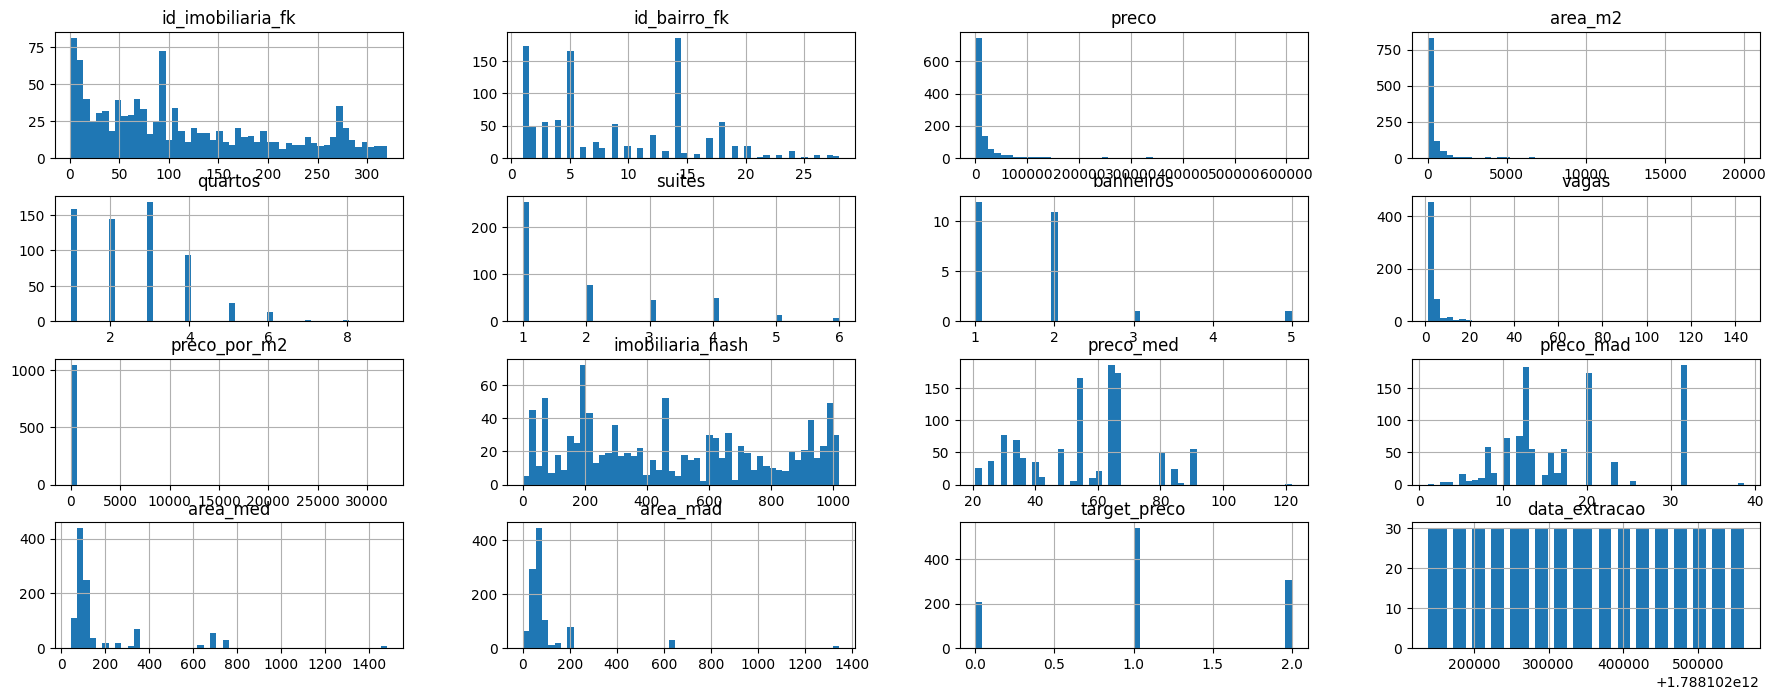

In [11]:
import matplotlib.pyplot as plt 
gold_imoveis.hist(bins=50, figsize=(22, 8))
plt.show()

In [12]:
gold_imoveis.describe().to_dict()

{'id_imobiliaria_fk': {'count': 1050.0,
  'mean': 114.03333333333333,
  'std': 91.20165817094535,
  'min': 1.0,
  '25%': 36.25,
  '50%': 93.0,
  '75%': 179.75,
  'max': 320.0},
 'id_bairro_fk': {'count': 1050.0,
  'mean': 8.741904761904761,
  'std': 6.5087062167744625,
  'min': 1.0,
  '25%': 3.0,
  '50%': 7.0,
  '75%': 14.0,
  'max': 28.0},
 'preco': {'count': 1050.0,
  'mean': 18740.861904761903,
  'std': 44675.167494339184,
  'min': 140.0,
  '25%': 3300.0,
  '50%': 6000.0,
  '75%': 15000.0,
  'max': 610000.0},
 'area_m2': {'count': 1048.0,
  'mean': 391.0763358778626,
  'std': 1106.3788062572314,
  'min': 1.0,
  '25%': 50.0,
  '50%': 110.0,
  '75%': 336.0,
  'max': 20000.0},
 'quartos': {'count': 609.0,
  'mean': 2.587848932676519,
  'std': 1.3484579900113083,
  'min': 1.0,
  '25%': 1.0,
  '50%': 3.0,
  '75%': 3.0,
  'max': 9.0},
 'suites': {'count': 447.0,
  'mean': 1.9015659955257271,
  'std': 1.268512161036545,
  'min': 1.0,
  '25%': 1.0,
  '50%': 1.0,
  '75%': 3.0,
  'max': 6.0},

## Análises das Estatísticas de cada coluna 

**area_m2**:
 -  há um imovel com area igual a 1 (verificar se foi erro de raspagem)
 -  verificar se os imoveis com area amxima (20 000 m2) são erros de raspagem

**quartos**:
  - há apenas 609(58%) imoveis dos 1050 com qtdade de quartos cadastrados, verificar se é erro de raspagem

**suites**:
  - o numero de imoveis com a informação de suites preenchida tbm é menor, verificar o porque
  - apenas 447 dos 1050, 42% preenchido

**banheiros**:
- apenas 25 linhas com a coluna banheiros não são nulos
- 2.4 % dos imoveis com esse dado preenchido

**vagas**:
- há um imovel com 144 vagas de acordo com a tabela (verificar se foi problema de raspagem)
- apenas 57% dos imoveis tem essa coluna preenchida (600 de 1050)

**preco**:
 - a tabela acima mostra que há imoveis cujo aluguel é de 140 reais (verificar a url e ver se foi erro de raspagem)
 - 25% dos alugueis custam menos de 3300 reais
 - 50% dos alugueis custam menos de 6000 reais
 - 75% dos alugueis custa menos de 15000 reais
 - há imoveis custando 610 000 reais (investigar se não foi erro na etapa de raspagem)

## Investigação

In [13]:
# Investigando imoveis com areas suspeitas

display(gold_imoveis["area_m2"].describe())
media_area = gold_imoveis["area_m2"].mean()
desv_pad_area = gold_imoveis["area_m2"].std()
print(f"O desvio padrão da coluna area_m2 é {desv_pad_area / media_area:.2f}x a media")

count     1048.000000
mean       391.076336
std       1106.378806
min          1.000000
25%         50.000000
50%        110.000000
75%        336.000000
max      20000.000000
Name: area_m2, dtype: float64

O desvio padrão da coluna area_m2 é 2.83x a media


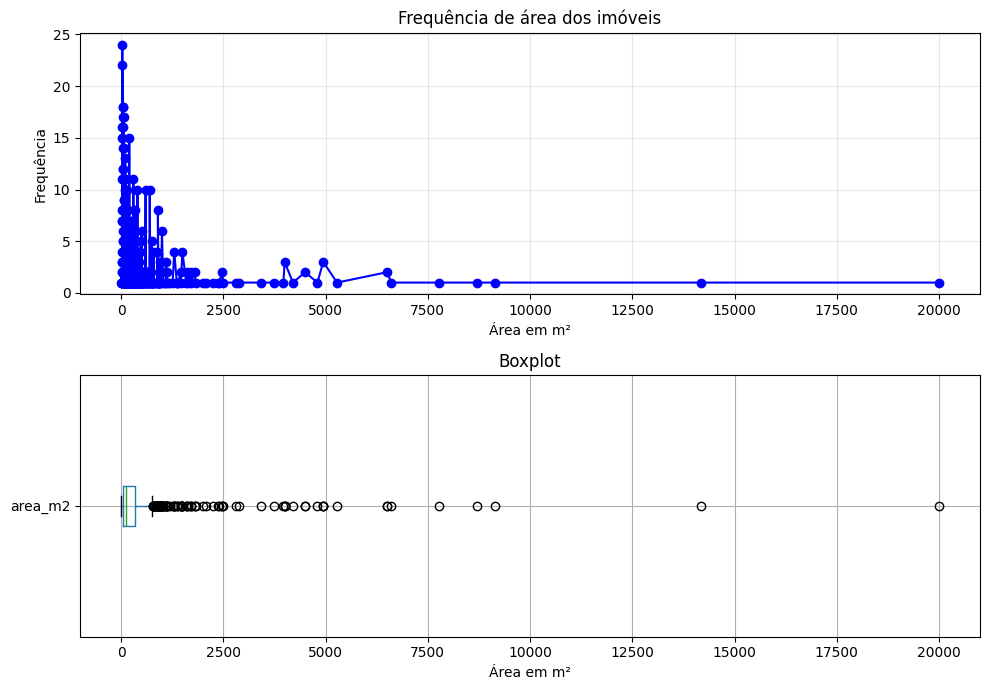

In [14]:
# Criando a figura com 2 subgráficos na mesma coluna (um em cima do outro)
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 7))

# 1. Gráfico de frequência no primeiro eixo (ax1)
# eixo x = valores de area_m2; eixo y = frequência de cada valor
freq_area = gold_imoveis['area_m2'].value_counts().sort_index()
ax1.plot(freq_area.index, freq_area.values, color='blue', marker='o', linewidth=1.5)
ax1.set_title('Frequência de área dos imóveis')
ax1.set_xlabel('Área em m²')
ax1.set_ylabel('Frequência')
ax1.grid(True, alpha=0.3)

# 2. Boxplot no segundo eixo (ax2)
gold_imoveis.boxplot(column=['area_m2'], ax=ax2, vert=False, grid=True)
ax2.set_title('Boxplot')
ax2.set_xlabel('Área em m²')

# Ajustando o layout para não sobrepor os títulos
plt.tight_layout()

# Exibindo a figura
plt.show()

In [15]:
limiar_area = 1000
imoveis_pequenos = gold_imoveis[gold_imoveis["area_m2"] <= limiar_area]
imoveis_grandes = gold_imoveis[gold_imoveis["area_m2"] > limiar_area]

print(gold_imoveis.shape)
print(imoveis_pequenos.shape)
print(imoveis_grandes.shape)

(1050, 25)
(979, 25)
(69, 25)


In [16]:
# Calculando os outliers para coluna de area
# Outlier Limite Suerior (LS)
#   LS:  Q3 + (1,5 * IRQ)
#   Q3:  75% percentil
#   IRQ: Q3 - Q1
#   Q1:  25% percentil

# Calulando Outliers Limite Inferior
# LI: Q1 - (1,5 * IRQ)

q1 = gold_imoveis["area_m2"].quantile(0.25)
q3 = gold_imoveis["area_m2"].quantile(0.75)
irq = q3 - q1
limite_superior =  q3 + (1.5 * irq)
limite_inferior = q1 - (1.5 * irq)
area_outlier_imoveis = gold_imoveis[(gold_imoveis["area_m2"] >= limite_superior) | (gold_imoveis["area_m2"] <= limite_inferior)]

print("Limite inferior:",limite_inferior)
print("Limite superior:",limite_superior)
print("Total de imoveis:",gold_imoveis.shape)
print("Outliers com area muito grande:",gold_imoveis[gold_imoveis.area_m2 >= limite_superior].shape[0])
print("Outliers com area muito pequena:",gold_imoveis[gold_imoveis.area_m2 <= limite_inferior].shape[0])
print("Total de outliers:",area_outlier_imoveis.shape[0])

Limite inferior: -379.0
Limite superior: 765.0
Total de imoveis: (1050, 25)
Outliers com area muito grande: 111
Outliers com area muito pequena: 0
Total de outliers: 111


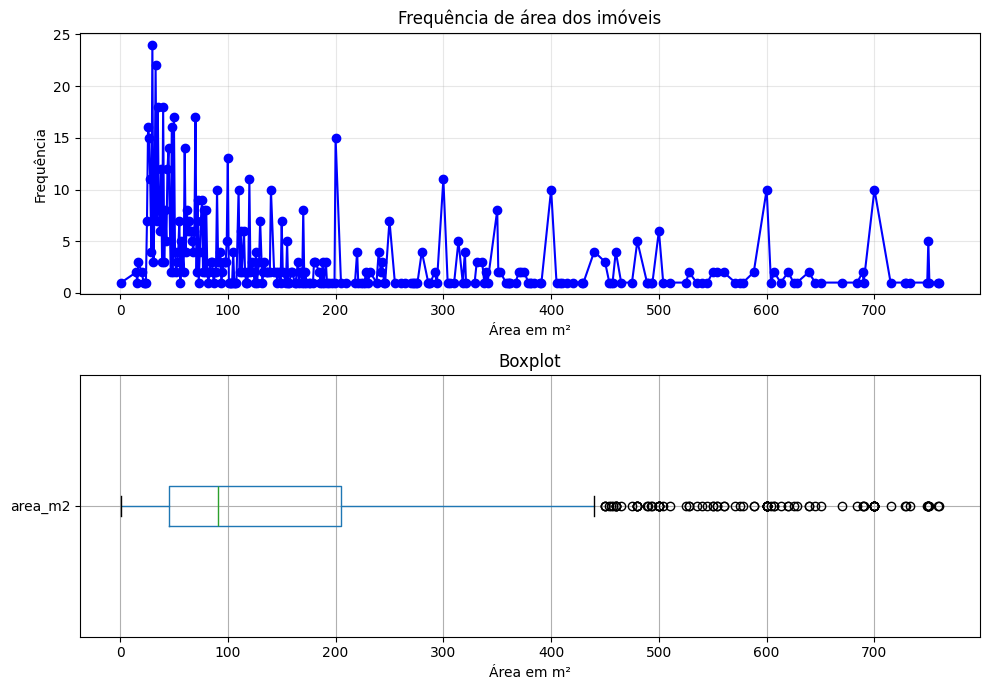

In [18]:
# df sem imoveis outliers
imoveis_sem_outliers = gold_imoveis[gold_imoveis["area_m2"] < q3 + (1.5 * irq)]

# Criando a figura com 2 subgráficos na mesma coluna (um em cima do outro)
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 7))

# 1. Gráfico de frequência no primeiro eixo (ax1)
# eixo x = valores de area_m2; eixo y = frequência de cada valor
freq_area = imoveis_sem_outliers['area_m2'].value_counts().sort_index()
ax1.plot(freq_area.index, freq_area.values, color='blue', marker='o', linewidth=1.5)
ax1.set_title('Frequência de área dos imóveis')
ax1.set_xlabel('Área em m²')
ax1.set_ylabel('Frequência')
ax1.grid(True, alpha=0.3)

# 2. Boxplot no segundo eixo (ax2)
imoveis_sem_outliers.boxplot(column=['area_m2'], ax=ax2, vert=False, grid=True)
ax2.set_title('Boxplot')
ax2.set_xlabel('Área em m²')
# Ajustando o layout para não sobrepor os títulos
plt.tight_layout()

# Exibindo a figura
plt.show()